# Why per-site phyloP finds no conserved sites on shallow trees

**A tree-length power ceiling, not a bug.**

The pipeline's phyloP branch (per-site LRT, `CONACC` mode, then genome-wide
Benjamini–Hochberg FDR) returns **essentially zero conserved sites** on hamsters,
birds, and turtles, while still returning accelerated sites — yet returns *millions*
of conserved sites on the 241-taxon Zoonomia mammal alignment. This notebook shows,
from the real fitted models and from simulation through the real tools, that this is a
**fundamental statistical-power limit set by total neutral tree length**, and quantifies
exactly where the wall is.

**Bottom line up front.** The maximum conservation signal a single site can carry is
capped by the total neutral branch length $T$: a perfectly conserved column is only as
surprising as the number of substitutions you *expected* across the tree. On the shallow
trees ($T\approx1$ subs/site) the most-conserved-possible site has $p\approx0.02$–$0.13$,
which cannot clear a genome-wide FDR bar of $\alpha/N\approx10^{-8}$ by ~six orders of
magnitude. You need $T\gtrsim10$ subs/site before *any* conserved site can pass. The
mammals ($T=16$) clear it; hamsters/birds/turtles ($T\approx0.9$–$2.8$) cannot, by
construction.


## 1. The observed problem

Conserved-site counts are ~0 across the shallow-tree datasets, while accelerated sites
are non-zero (e.g. hamster `test5`: `CM001010.3` conserved **0** / accelerated **167**).
A prior investigation
([`analyses/conserved-site-checks/test5-phylop-conserved-site-investigation.md`](../conserved-site-checks/test5-phylop-conserved-site-investigation.md))
already ruled out the mechanical explanations:

- MAF extraction — verified **byte-for-byte identical** to the source (SHA-256 match);
- downstream naive clustering, workflow logic, neutral-model collapse — all cleared.

Its bottom line: *conserved-class rows exist, but essentially none survive FDR, while
accelerated-class rows do.* What it did not identify is **why**. That "why" is the subject
of this note.

The one variable that separates the datasets is **total neutral tree length** $T$
(sum of branch lengths in the fitted neutral model, in expected substitutions/site):

| dataset | tips | $T$ (subs/site) | conserved sites |
|---|---|---|---|
| hamster | 15 | 0.93 | ~0 |
| birds | 44 | 1.09 | ~0 |
| turtle | 22 | 2.81 | ~0 |
| **mammal (Zoonomia)** | **241** | **16.07** | **millions** |


## 2. How the pipeline calls conserved sites

The phyloP path ([`workflow/phylop_regions.smk`](../../workflow/phylop_regions.smk)):

1. `phyloP --method LRT --mode CONACC --wig-scores` → a signed per-site score that is
   $-\log_{10}(p)$, **positive for conservation, negative for acceleration**
   ([`utils/convert_wig_to_bed.awk`](../../utils/convert_wig_to_bed.awk) recovers
   $p = 10^{-\lvert\text{score}\rvert}$).
2. Benjamini–Hochberg FDR across **all sites in the chromosome**
   ([`utils/adjust_pvals.sh`](../../utils/adjust_pvals.sh)).
3. Conserved sites = class `0` (score $>0$) **and** FDR-significant
   ([`utils/get_conserved_sites.awk`](../../utils/get_conserved_sites.awk)).

So a conserved call requires a site whose conserved-direction $p$-value survives
genome-wide multiple-testing correction. With $N\sim$ millions of sites per chromosome,
the smallest $p$ must beat $\approx\alpha/N \sim 10^{-8}$.


## 3. The mechanism: tree length caps the conserved score

### 3.1 The score and the test

phyloP's LRT fits a single scale parameter $\rho$ that multiplies every branch of the
neutral model ($\rho=1$ neutral, $\rho<1$ conserved). The statistic is
$\text{LRT}=2[\log L(\hat\rho)-\log L(\rho=1)]$, and — validated against the real binary
below — the `CONACC` conserved $p$-value uses the **full** $\chi^2_1$ tail:

$$p = P(\chi^2_1 \ge \text{LRT}) = 2\,\Phi(-\sqrt{\text{LRT}}).$$

### 3.2 The ceiling

The *most conserved possible* site is a column with **zero substitutions**. There the MLE
is $\hat\rho\to 0$ (fewer substitutions is always more likely), so $\log L(\hat\rho)=\log\pi_b$
and

$$\text{LRT}_{\max}(b) = 2\Big[\log\pi_b - \log P(\text{all leaves}=b\mid\text{neutral tree})\Big].$$

$P(\text{fully conserved}\mid\text{neutral})$ falls ~exponentially as the tree lengthens
(more expected substitutions ⇒ a conserved column is more surprising), so
$\text{LRT}_{\max}\approx\kappa\,T$ with $\kappa\approx2$–$3$ (model-dependent). The
score ceiling is then $-\log_{10}\!\big(2\Phi(-\sqrt{\text{LRT}_{\max}})\big)$.

### 3.3 Where the "≈ 1.3 × T" came from

Composing those two steps, the ceiling is
$-\log_{10}\!\big(2\Phi(-\sqrt{\kappa T})\big)$. This is **concave**, not linear — the
ratio ceiling$/T$ is ~1.3 only in the shallow regime where these datasets live
($T\approx1$), and *declines* for deeper trees:

| $T$ | 1.0 | 1.35 | 2 | 5 | 16 |
|---|---|---|---|---|---|
| ceiling $/\,T$ | 1.45 | 1.29 | 1.14 | 0.92 | 0.79 |

So "$1.3\times T$" is a shallow-tree local approximation (the secant slope near $T\approx1$),
not a universal constant. Practically it means you **cannot** linearly extrapolate it: needing
ceiling $\ge -\log_{10}(\alpha/N)\approx8$ does *not* give $T\approx6$; the concave curve
requires $T\approx10$–$11$.

### 3.4 The same thing in GERP's language

GERP (Cooper et al. 2005; Davydov et al. 2010) makes the ceiling explicit: it scores a
site in **"rejected substitutions"** —
> "the number of substitutions expected under neutrality minus the number of substitutions
> 'observed' at the position" (Davydov et al. 2010, [PMC2996323](https://pmc.ncbi.nlm.nih.gov/articles/PMC2996323/)).

A site can reject *at most* the number of substitutions the neutral tree expected there —
i.e. the maximum conserved score is bounded by the neutral tree length $T$. Short tree →
small ceiling, by construction.


In [ ]:
# Analytic ceiling from the real fitted models (Felsenstein pruning; numpy only).
# Full implementation: phylop_power.py ; figure: 01_analytic_ceiling.py
import phylop_power as pp
REPO = '../..'
families = {
    'hamster (15 sp)': 'data/hamsters/workflow-tests/test-full/02-neutral-model/phylofit/autosomes/CM000995.3-corrected.mod',
    'birds (44 sp)':   'data/birds/test1/03-phylofit/group1/chr10-corrected.mod',
    'turtle (22 sp)':  'data/turtles/small-test2/03-phylofit/shortest-scaffolds/NC_050095.1-corrected.mod',
    'mammal (241 sp)': 'data/mammals-v3/echolocation-v3/02-neutral-model/phylofit/autosomes/chr1-corrected.mod',
}
for name, mod in families.items():
    c = pp.ceiling(pp.parse_mod(f'{REPO}/{mod}'))
    print(f"{name:<16} T={c['tree_length']:6.2f}  ceiling -log10p={c['neglog10p']:6.2f} "
          f"(p={10**-c['neglog10p']:.1e})  kappa={c['kappa']:.2f}")


Output (committed in `analytic_ceiling_table.csv`):

```
hamster (15 sp)  T=  0.93  ceiling -log10p=  0.89 (p=1.3e-01)  kappa=2.48
birds (44 sp)    T=  1.09  ceiling -log10p=  1.15 (p=7.1e-02)  kappa=2.98
turtle (22 sp)   T=  2.81  ceiling -log10p=  1.75 (p=1.8e-02)  kappa=1.99
mammal (241 sp)  T= 16.07  ceiling -log10p= 11.52 (p=3.0e-12)  kappa=3.03
```

The figure below sweeps $T$ (by rescaling each family's real tree) and overlays the
genome-wide BH bar $-\log_{10}(\alpha/N)$ for a range of per-chromosome site counts $N$.
The three shallow families sit at the very bottom, ~6 orders of magnitude under the bar;
only the mammal clears it.

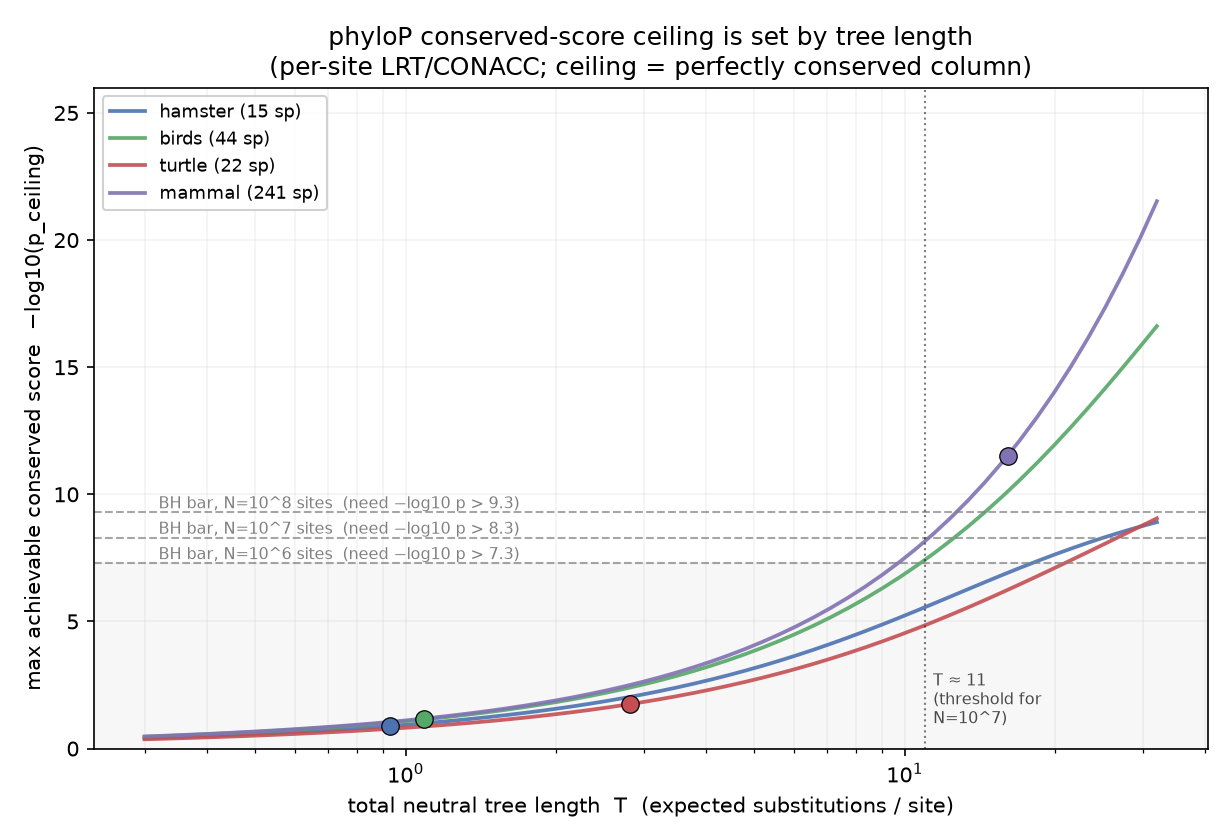

In [ ]:
# Regenerate with: python 01_analytic_ceiling.py
from IPython.display import Image
Image('figures/analytic_ceiling_vs_treelen.png')


### 3.5 The threshold, and the conservation/acceleration asymmetry

Inverting the (concave) ceiling: a conserved site can clear genome-wide FDR only once

$$-\log_{10}\!\big(2\Phi(-\sqrt{\kappa T})\big)\;\ge\;-\log_{10}(\alpha/N),$$

which for $\kappa\approx3,\ N\approx6\times10^{6},\ \alpha=0.05$ needs **$T\gtrsim10$–$11$
subs/site**. Hamsters/birds/turtles ($T\approx0.9$–$2.8$) are ~4–10× short; mammals
($T=16$) clear it.

**Why acceleration survives but conservation doesn't.** Conservation is *bounded* — a site
cannot have fewer than zero substitutions, so its score is capped by $T$. Acceleration is
*unbounded* — a site can have far **more** substitutions than expected (e.g. a turtle
scaffold's best accelerated site reached $p=5.6\times10^{-10}$ while its best *conserved*
site was floored at $p=0.018$). So per-site `CONACC` + genome-wide FDR structurally selects
**for** acceleration and **against** conservation on short trees — exactly the observed
pattern (conserved 0, accelerated non-zero).

### 3.6 The full picture: tree length × number of sites

Detectability is a **race between two quantities**:

- the **ceiling** on the conserved score, set by tree length: $\text{ceiling}(T)=-\log_{10}(2\Phi(-\sqrt{\kappa T}))$;
- the **bar** a site must clear, set by the number of tested sites: $\text{bar}(N)=-\log_{10}(\alpha/N)$.

A conserved site is recoverable only where $\text{ceiling}(T)\ge\text{bar}(N)$. The heatmap
below maps the margin $\text{ceiling}(T)-\text{bar}(N)$ over the $(T,N)$ plane; the black
curve is the detectability boundary. The largest $N$ still detectable grows explosively
with $T$:

| $T$ | 1 | 2 | 5 | 10 | 16 | 24 |
|---|---|---|---|---|---|---|
| largest detectable $N$ | <1 | ~4 | ~6×10² | ~1.6×10⁶ | ~1.5×10¹⁰ | ~2×10¹⁵ |

Two things to read off it: (i) at genome scale ($N\sim10^6$–$10^8$) you need
$T\approx10$–$13$; (ii) on the shallowest trees ($T\approx1$) the ceiling is so low that
a conserved site can't reach $p<0.05$ **even with $N=1$** — i.e. no amount of relaxing the
multiple-testing correction rescues it. All three shallow families sit far inside the
"nothing passes" region for any realistic $N$; only the mammals cross into the detectable
zone. (The surface uses the mammal model's $\kappa$; the mild model-dependence of $\kappa$
shifts the boundary by less than one tree-length unit.)

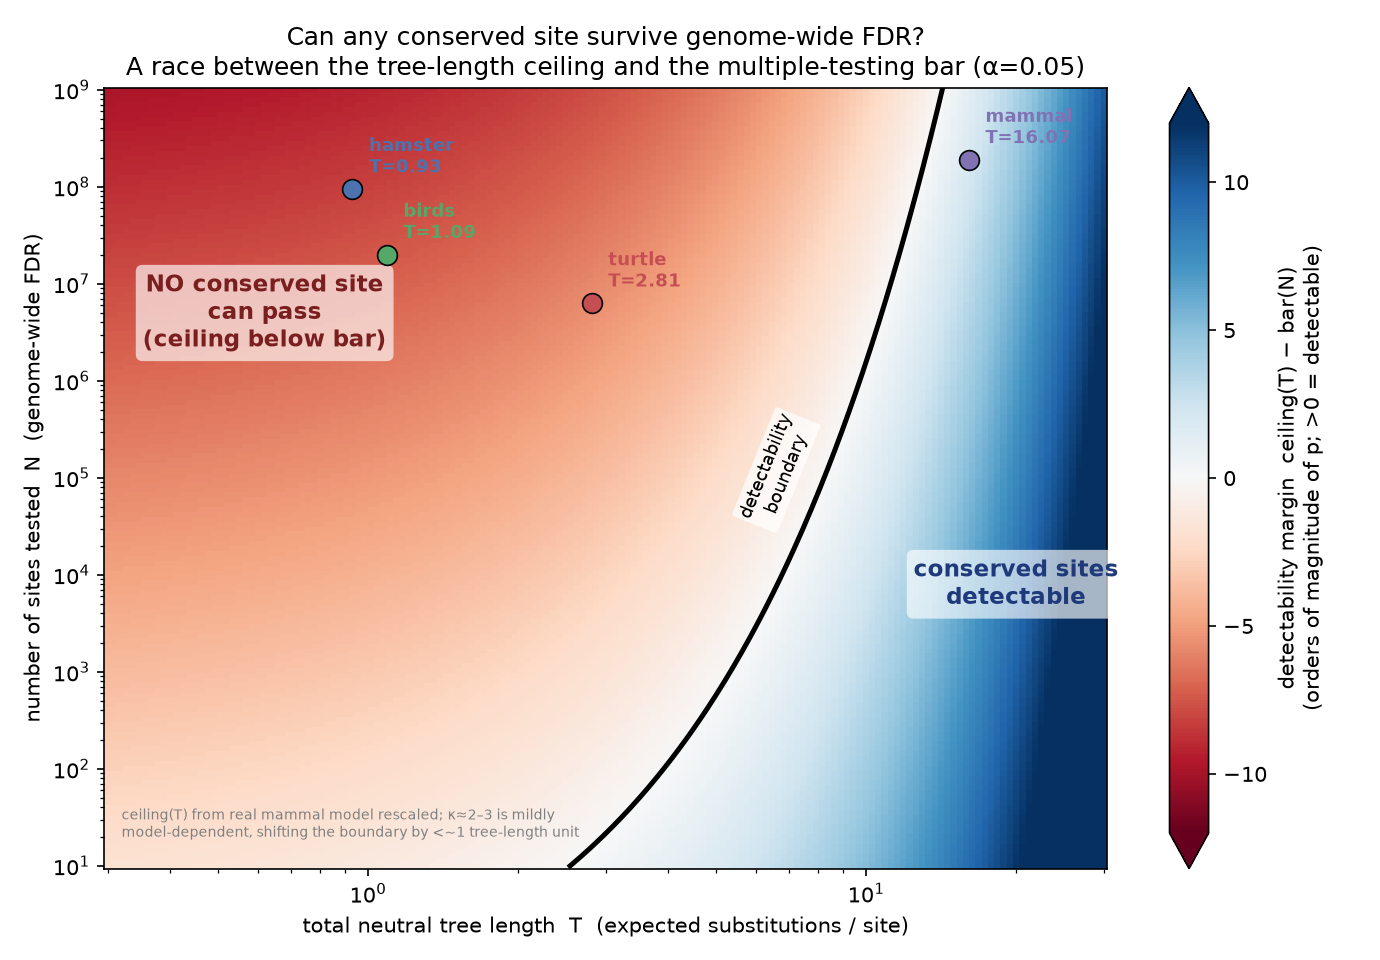

In [ ]:
# Regenerate with: python 04_detectability_heatmap.py
from IPython.display import Image
Image('figures/detectability_heatmap.png')


## 4. Validation against the real tool and real data

The analytic ceiling is not just theory — it matches the real `phyloP` binary and the real
pipeline output three ways (turtle model, $T=2.81$):

| source | conserved-score ceiling |
|---|---|
| analytic (`phylop_power.ceiling`) | **1.746** |
| real `phyloP` on a fully-conserved probe column | **1.733** |
| max conserved score in the real `*-phylop.bed` output | **1.746** |

and for the mammal model ($T=16.07$): analytic **11.52** vs sampled real-data max **11.52**.

Finding this match is also what pinned down the $p$-value convention: the real binary's
1.733 forced the **full $\chi^2_1$ tail** ($2\Phi(-\sqrt{\text{LRT}})$); the one-sided form
overestimates $-\log_{10}p$ by $\log_{10}2\approx0.30$ and would have read 2.05.

## 5. Simulation: the power wall, end-to-end through the real tools

Analytic ceilings describe the *best possible* case (perfect conservation). Do genuinely
conserved elements actually get recovered? To test it we hold topology and substitution
model fixed (the real 241-taxon mammal model) and vary **only** total tree length $T$ by
rescaling branches. At each $T$ we use **AliSim** (bundled in IQ-TREE 3) to evolve:

- a **neutral background** (100 kb, branches at $T$), and
- a **genuinely conserved block** (5 kb, branches at $0.1\times T$ — evolving at 10% of the
  neutral rate),

score every site with the **real `phyloP`**, apply the pipeline's **exact BH-FDR**, and
measure the fraction of the conserved block recovered.

**Which tree?** Every one of the seven simulation points uses the *same* real tree — the
**241-taxon mammal neutral topology and its fitted GTR model** — with branch lengths
uniformly rescaled to hit each target $T$ (and rescaled a further $\times0.1$ for the
conserved block). Holding topology and model fixed is deliberate: it isolates $T$ as the
single variable, including at the shallow-$T$ points. This is justified by the analytic
figure (§3), which *does* use each family's own real tree (15–241 taxa) and finds the
ceiling curves nearly coincide vs $T$ — i.e. at a given $T$, taxon count and topology
barely move the ceiling, so one rescaled topology is a fair stand-in.

> *Simulated data used here was explicitly approved for this task.* The simulator is
> AliSim (`iqtree3`, already installed); driver: `02_simulate_power.py`.


In [ ]:
# Simulation results (produced by 02_simulate_power.py; committed in sim_power_results.csv)
import csv
with open('sim_power_results.csv') as f:
    for r in csv.DictReader(f):
        print(f"T={float(r['T']):5.1f}  sensitivity={float(r['sensitivity_pct']):6.2f}%  "
              f"recovered={r['conserved_recovered']:>4}/{r['conserved_total']}  "
              f"max_cons_score={float(r['max_conserved_score']):5.2f}  FP_bg={r['false_positives_bg']}")


```
T=  1.0  sensitivity=  0.00%  recovered=   0/5000  max_cons_score= 1.11  FP_bg=0
T=  2.0  sensitivity=  0.00%  recovered=   0/5000  max_cons_score= 1.89  FP_bg=0
T=  4.0  sensitivity=  0.00%  recovered=   0/5000  max_cons_score= 3.36  FP_bg=0
T=  8.0  sensitivity= 70.66%  recovered=3533/5000  max_cons_score= 6.14  FP_bg=290
T= 12.0  sensitivity= 77.40%  recovered=3870/5000  max_cons_score= 8.84  FP_bg=102
T= 16.0  sensitivity= 96.54%  recovered=4827/5000  max_cons_score=11.47  FP_bg=157
T= 24.0  sensitivity= 99.70%  recovered=4985/5000  max_cons_score=20.00  FP_bg=151
```

On shallow trees, **zero** of 5000 genuinely-conserved sites are recovered — not a few,
*zero* — even though they evolve at a tenth of the neutral rate. Detection switches on only
past $T\approx8$ and is near-complete by $T=16$. The false-positive counts stay controlled
(FDR is working correctly; the conserved calls are missing for lack of *power*, not because
FDR is miscalibrated). Note this sim uses $N\approx10^5$ sites — a *gentler* bar than a real
$N\approx6\times10^6$ chromosome, so the real-genome threshold is if anything **higher**.

The left panel places the four real families on this curve: hamster/bird/turtle land squarely
in the 0%-recovery zone; the mammal lands at 97%. The right panel shows the simulation's
max score tracking the analytic ceiling through the FDR bar.

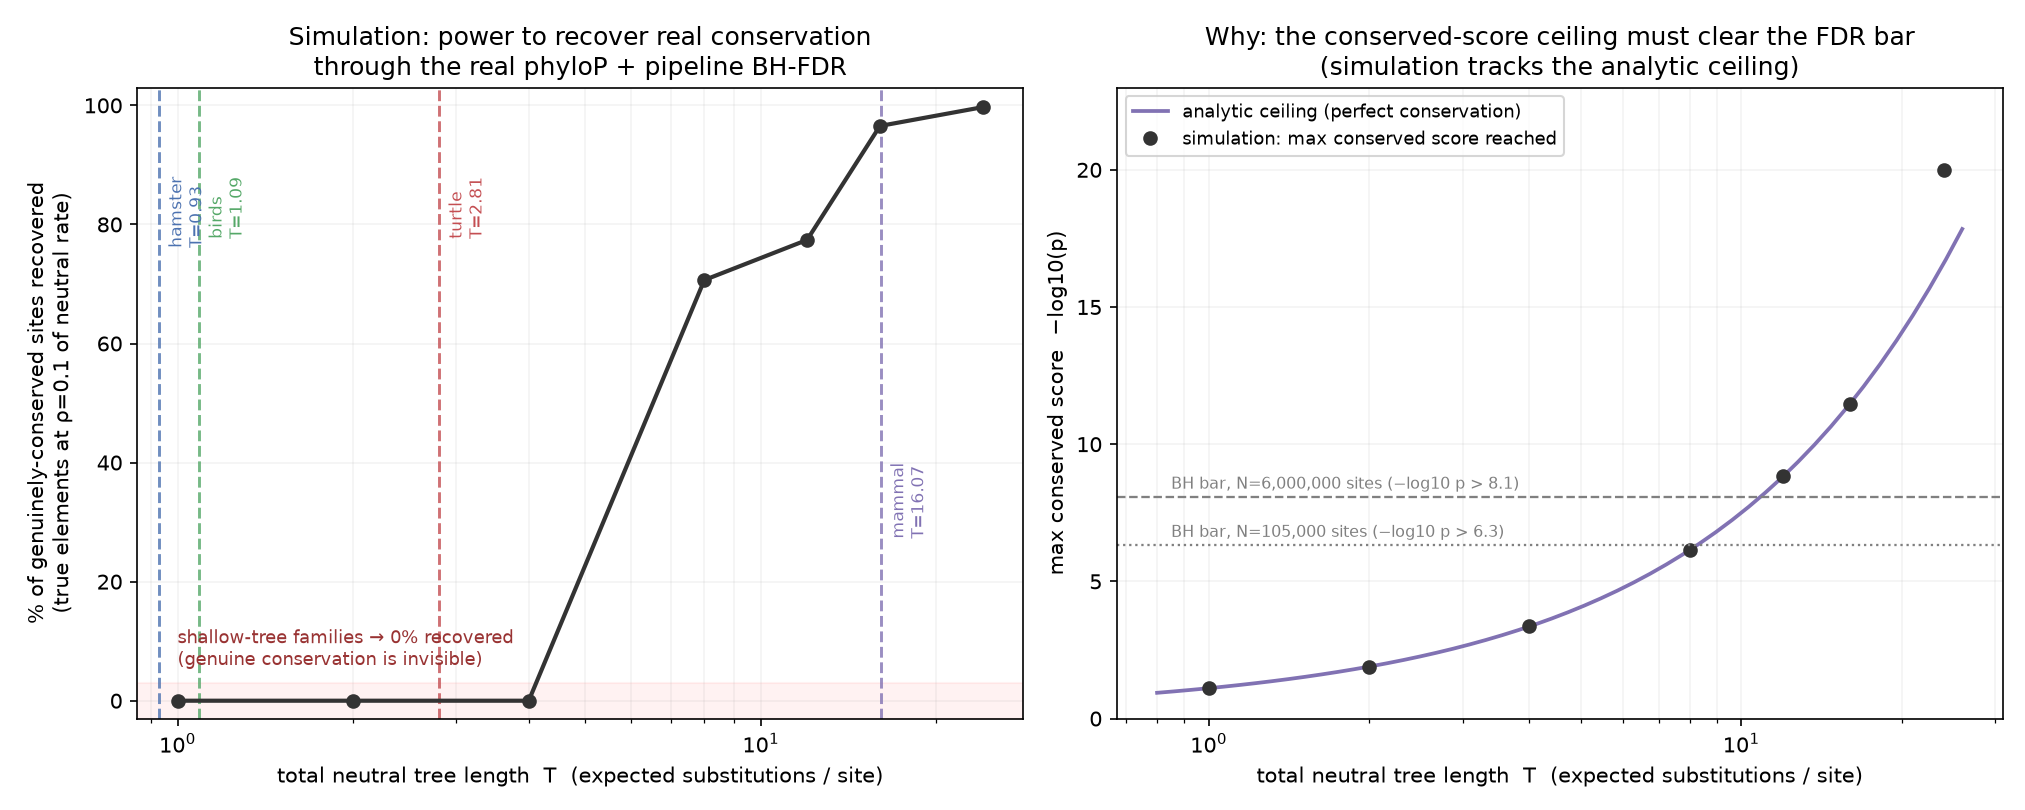

In [ ]:
# Regenerate with: python 03_plot_sim.py
from IPython.display import Image
Image('figures/sim_power_vs_treelen.png')


## 6. From single bases to elements: minimum detectable size, and the 29→241 mammal landmarks

The single-base ceiling has a direct extension that answers a practical question: **how
big must a conserved element be to be detectable on a given tree?** The key is that
**evidence adds across sites**. Define

$$P_1(T) = \text{probability a }\textbf{neutral}\text{ single base is invariant (identical in all species)},$$

computed exactly from the neutral model. A neutral $L$-mer is entirely invariant with
probability $\approx P_1(T)^L$, so an all-conserved element of length $L$ is detectable when
that is rarer than the genome-wide bar, $P_1(T)^L < \alpha/N$. Solving:

$$\boxed{\,L_{\min}(T,N) \;=\; \frac{\ln(N/\alpha)}{\ln(1/P_1(T))}\,}$$

Two consequences: minimum element size shrinks roughly **inversely with tree length**
($\ln(1/P_1)$ grows with $T$), and depends only **logarithmically** on the number of tests
$N$. Double the tree → roughly halve the resolvable element.

**This is exactly the framework of the 29-mammals paper** (Lindblad-Toh et al. 2011), which
argued resolution in terms of $P_1$ (single base) and $P_{12}$ (12-mer). Reassuringly, our
models reproduce their numbers from scratch.

In [ ]:
import math
import phylop_power as pp
REPO = '../..'
mam = pp.parse_mod(f'{REPO}/data/mammals-v3/echolocation-v3/02-neutral-model/phylofit/autosomes/chr1-corrected.mod')
Tbase = pp.tree_length(pp.parse_newick(mam['tree_newick']))
P1_45 = pp.invariant_probability(mam, 4.5 / Tbase)   # rescale mammal tree to T=4.5 (29-mammals depth)
print(f'cross-check at T=4.5 (29 mammals):  our P1 = {P1_45:.4f}  (paper: P1 < 0.02)')
print(f'                                    our P1^12 = {P1_45**12:.1e}  (paper: P12 < 1e-25)')

# two criteria (both for a perfectly-conserved element):
#   exact P1:  L_min = ln(N/alpha)/ln(1/P1)          (conservative; 29-mammals paper)
#   phyloP X2: element p = 2*Phi(-sqrt(L*LRT/site))  (what pipeline & Zoonomia use)
def Lmin_exact(P1, N=1e8, a=0.05): return math.log(N/a)/math.log(1/P1)
def Lmin_chi2(lrt, N=1e8, a=0.05):
    tgt=math.log10(N/a); lo,hi=1e-3,1e5
    for _ in range(80):
        m=math.sqrt(lo*hi)
        lo,hi=(m,hi) if pp.neglog10_from_lrt(m*lrt)<tgt else (lo,m)
    return math.sqrt(lo*hi)
fams = {'hamster':'data/hamsters/workflow-tests/test-full/02-neutral-model/phylofit/autosomes/CM000995.3-corrected.mod',
        'birds':'data/birds/test1/03-phylofit/group1/chr10-corrected.mod',
        'turtle':'data/turtles/small-test2/03-phylofit/shortest-scaffolds/NC_050095.1-corrected.mod',
        'mammal':'data/mammals-v3/echolocation-v3/02-neutral-model/phylofit/autosomes/chr1-corrected.mod'}
for name, mod in fams.items():
    lrt = pp.ceiling(pp.parse_mod(f'{REPO}/{mod}'))['LRT_max']
    print(f'{name:<8} min conserved element ~ {Lmin_chi2(lrt):4.0f} bp')


Output:

```
cross-check at T=4.5 (29 mammals):  our P1 = 0.0234  (paper: P1 < 0.02)
                                    our P1^12 = 2.6e-20  (paper: P12 < 1e-25)
hamster  min conserved element ~   17 bp
birds    min conserved element ~   12 bp
turtle   min conserved element ~    7 bp
mammal   min conserved element ~ <1 bp   (single base)
```

So the resolution on your datasets:

| dataset | T | min conserved element |
|---|---|---|
| hamster | 0.93 | **~17 bp** |
| birds | 1.09 | **~12 bp** |
| turtle | 2.81 | **~7 bp** |
| mammal / Zoonomia | 16.07 | **single base** |

These use phyloP's actual scoring (the χ² p-value your pipeline computes). *(The exact
invariant-probability criterion used by the 29-mammals paper is a few bp more conservative —
same story, so we report the operative one here.)*

**Read these as hard lower bounds.** They are the size of a *perfectly conserved* element
(every base identical in all species) — so nothing **shorter** is detectable at *any*
conservation level (e.g. no conserved element under ~7 bp is findable on the turtle tree).
Real conserved elements evolve slowly but not at zero, so they carry less signal per base
and must be **somewhat larger** than these floors. That direction is certain; the *size* of
that correction is **not quantified here** (it depends on how strongly the element is
conserved and would need a dedicated simulation) — we deliberately do not put a number on
it.

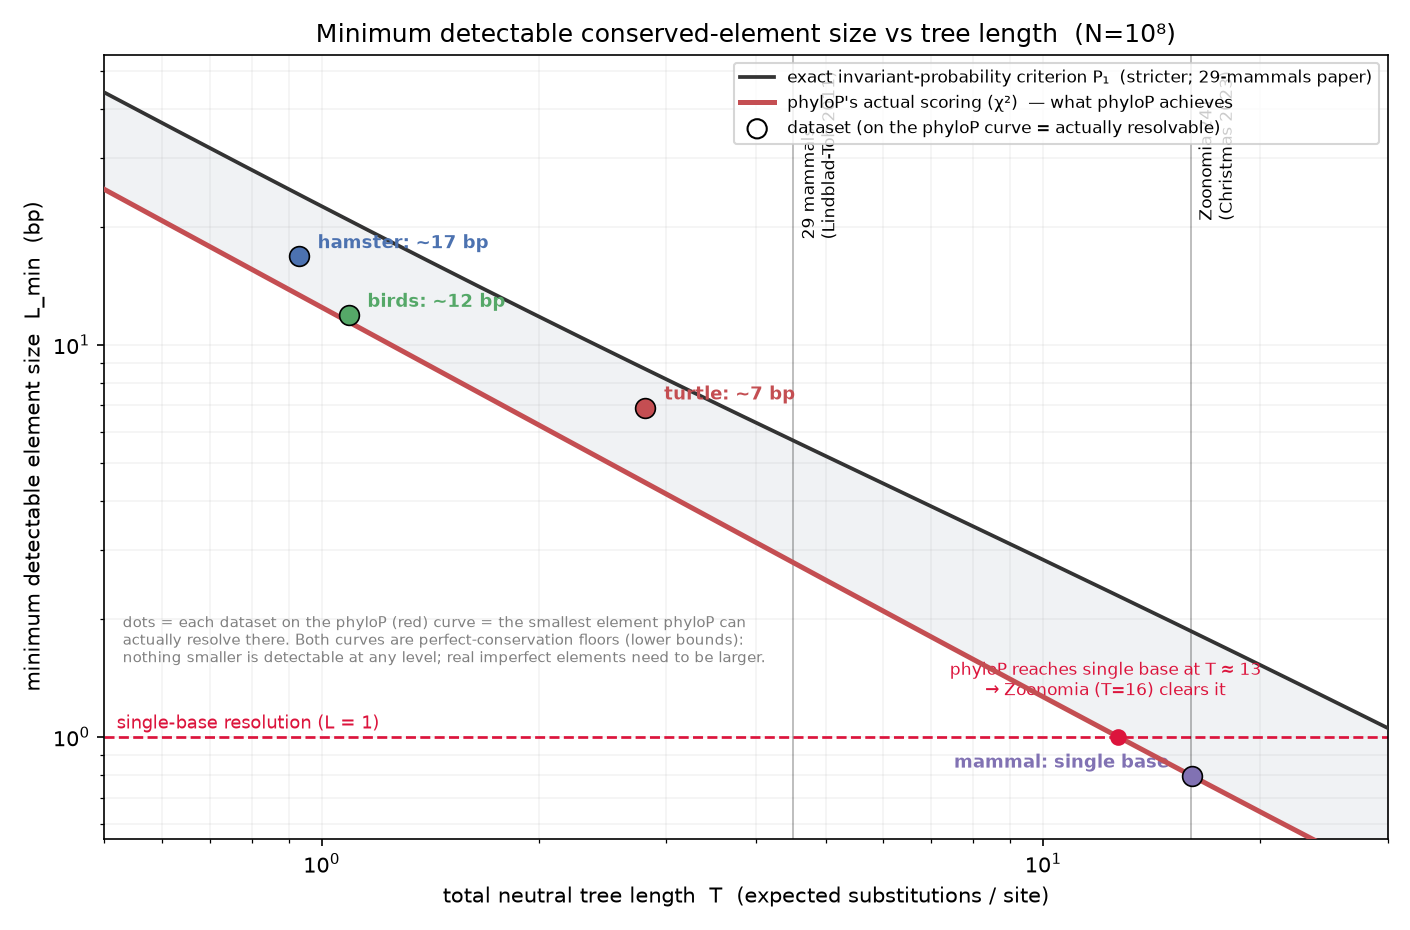

In [ ]:
# Regenerate with: python 05_element_size.py
from IPython.display import Image
Image('figures/min_element_size.png')


### The two mammalian landmark datasets bracket the threshold

Our theoretical curve is anchored by the two datasets that define the field's resolution
history — and it reproduces both:

**29 mammals — Lindblad-Toh et al. 2011, *Nature* 478:476–482
([doi:10.1038/nature10530](https://www.nature.com/articles/nature10530)):**
the 29-mammal tree has "a total effective branch length of ~4.5 substitutions per site,"
and "the probability that a genomic sequence not under purifying selection will remain fixed
across all 29 species is **P₁ < 0.02 for single bases** and **P₁₂ < 10⁻²⁵ for 12-mers**"
(they estimated ~4.2% of the human genome under constraint). So at T≈4.5, a single invariant
base ($P_1$≈0.02) is *not* genome-wide significant, but a fully-invariant 12-mer
($P_{12}$≈10⁻²⁵) is trivially so — i.e. 12-mers were their *illustration* that short elements
are easily detectable at this depth, **not** a claim that 12 bp is the smallest resolvable
element. Our model independently reproduces both: P₁ = 0.023 and P₁¹² = 2.6×10⁻²⁰.

**Zoonomia 241 mammals — Christmas et al. 2023, *Science* 380:eabn3943
([doi:10.1126/science.abn3943](https://www.science.org/doi/10.1126/science.abn3943)):**
species were "selected to maximize the evolutionary branch length" and the 241-mammal phyloP
scores "achieve single-base resolution of evolutionary constraint," identifying ~332 Mb
(~10.7% of the human genome) as constrained. This is essentially **your `mammals-v3`
dataset** (T=16.07). On the figure above, phyloP's actual (χ²) curve crosses below L=1
at T≈13, so at T=16 single bases clear the bar — **Zoonomia's published single-base
resolution is exactly what our curve predicts at this depth.**

So the field went from **elements-only (29-way, T≈4.5)** to **single-base (241-way, T≈16)** by
adding branch length — precisely the axis of this whole analysis, and your shallow-tree
datasets sit well below even the 29-way landmark.

*Why two curves?* $P_1$ is the **exact** invariant probability (the 29-mammals paper's
criterion); phyloP's reported per-base p-value (used in §3, by the pipeline, and by
Zoonomia) is an asymptotic ($\chi^2$) approximation to the same idea, and is
anticonservative in the deep tail — so it reaches single bases a bit sooner (T≈13 vs
T≈25 for exact $P_1$). The two **agree completely on the shallow-tree verdict** (both put
hamster/birds/turtle far from single-base, needing ~10–25 bp elements) and on the
$\propto 1/T$ scaling; they diverge only in the deep single-base regime, which is why the
figure shows the band. The operative curve for what the pipeline actually does is the
χ² one.

## 7. What the literature says (methods)

This is a known, expected limitation in the Siepel-lab methods papers — not a novel bug.
*(Quotes below were pulled from the linked PMC full texts; see the sources for exact context.)*

**phyloP — Pollard, Hubisz, Rosenbloom & Siepel 2010, *Genome Research*
([PMC2798823](https://pmc.ncbi.nlm.nih.gov/articles/PMC2798823/)):**
> "Power increases with the magnitude of the departure from the neutral model (as measured by
> ρ or λ), the length of the element, and the number of species affected."

> "While it is premature to claim single-nucleotide resolution in the detection of nonneutral
> substitution rates, elements 1–3 bp in length can be detected with reasonable power" — and,
> for shallow subtrees, "power is poor for individual nucleotides."

phyloP was developed and validated on the **deep** ~30-way mammalian alignment for exactly
this reason.

**phastCons — Siepel et al. 2005, *Genome Research*
([PMC1182216](https://pmc.ncbi.nlm.nih.gov/articles/PMC1182216/)):**
> The phylo-HMM "considers both the process by which nucleotide substitutions occur at each
> site in a genome and how this process changes from one site to the next."

By **pooling information across neighboring sites**, phastCons has power where a per-site test
has none — which is almost certainly why the pipeline's phastCons/CNEE branch produces output
on the same shallow datasets where per-site phyloP returns nothing.

**GERP++ — Davydov et al. 2010, *PLoS Comput Biol*
([PMC2996323](https://pmc.ncbi.nlm.nih.gov/articles/PMC2996323/)):**
> constraint is quantified in "rejected substitutions (RS), the difference between the neutral
> rate of substitution and the observed rate."

The maximum RS at a site is the neutral rate itself — the ceiling, in GERP's own terms.


## 8. Bottom line

The missing conserved phyloP sites on hamsters/birds/turtles are **not** a bug in extraction,
FDR, or clustering. Per-site phyloP conservation runs into a hard statistical wall set by
total neutral tree length: below $T\approx10$ subs/site, no single conserved site can clear
genome-wide FDR, and the shallow-tree datasets sit far under that. The mammal alignment
($T=16$) is the only one deep enough. Acceleration still appears because it is unbounded.

**Directions** (to discuss separately — this note is the diagnosis, not the fix): (1) score
**windows/elements** instead of single bases (phyloP `-w`/`--features`: more signal per test
*and* far fewer tests); (2) use **phastCons** for shallow trees (already in the pipeline, and
the reason it produces output here); (3) window-level or empirical-null significance instead of
per-base genome-wide FDR; (4) add taxa / deepen the tree. Options 1–2 fit what the pipeline
already has.


## 9. Reproducibility

All computation runs in the repo's `phyloacc-workflows` conda env (numpy/matplotlib/pandas;
**no scipy or extra installs** — matrix exponentials use numpy eigendecomposition). The
simulation additionally uses **AliSim** (bundled in `iqtree3`, `iqtree-env`) and the real
`phyloP` (`phast`).

| file | what |
|---|---|
| `phylop_power.py` | `.mod` parser + Felsenstein pruning + conserved-score ceiling (library) |
| `01_analytic_ceiling.py` | Figure 1 (ceiling vs T) + `analytic_ceiling_table.csv` (no simulated data) |
| `02_simulate_power.py` | AliSim power sweep → `sim_power_results.csv` (simulated data, approved) |
| `03_plot_sim.py` | Figure 2 (simulation power) from the sweep results |
| `04_detectability_heatmap.py` | Figure 3 (T × N detectability heatmap; no simulated data) |
| `05_element_size.py` | Figure 4 (minimum detectable element size vs T; no simulated data) |
| `build_notebook.py` | assembles this notebook + renders the HTML from the committed figures/tables |

```bash
conda activate phyloacc-workflows
cd analyses/phylop-tree-length-power
python 01_analytic_ceiling.py        # analytic figure + table
PATH="$CONDA_PREFIX/../iqtree-env/bin:$PATH" python 02_simulate_power.py   # sim sweep (slow)
python 03_plot_sim.py                # sim figure
python build_notebook.py             # rebuild the .ipynb
```
